Reactions:
At A :2.875kN
At D :7.125kN

 Shear Forces:
0 m:2.875kN
2 m:-0.12499999999999956kN
4 m:-0.12499999999999956kN
8 m:3.0kN
9 m:3.0kN

 Bending Moments:
0 m:0kN.m
2 m:5.75kN.m
4 m:5.500000000000001kN.m
8 m:-3kN.m
9 m:0kN.m


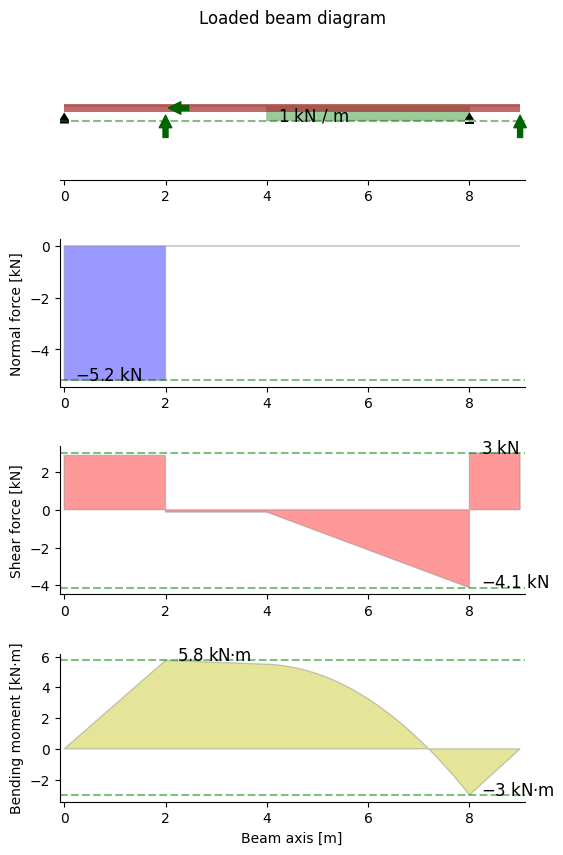

In [1]:
import numpy as np
from beambending import DistributedLoadV, PointLoadH, PointLoadV,x
from beambending import Beam


beam = Beam(9)  # Initialize a Beam object of length 9m
beam.pinned_support = 0    # x-coordinate of the pinned support
beam.rolling_support = 8  # x-coordinate of the rolling support



class calculate_beam():
    
    #BEAM DATA/INPUT VALAUES
    length_AB = 2   #m
    length_BC = 2   #m
    length_CD = 4   #m
    overhang_DE = 1  #m
    
    load_B = 6     #N
    UDL_CD = 1     #kN/m
    load_E = 3     #N

    
    total_length = length_AB + length_BC + length_CD + overhang_DE
    total_load_CD =  (UDL_CD * length_CD)
    
    #resolving inclined force at B vertically
    load_B_vertical = load_B * np.sin(np.radians(30))
    #resolving inclined force at B horizontally
    load_B_horizontal = load_B * np.cos(np.radians(30))
    
    
    #calculating reaction forces at point A and D
    reaction_D = ((load_E * total_length)+(total_load_CD * (length_AB + length_BC + (length_CD/2)))+(load_B_vertical*length_AB))/(length_AB+length_BC+length_CD)
    reaction_A = (load_E + total_load_CD + load_B_vertical ) - (reaction_D)
    
    #calculating shear forces at point A,B,C,D and E
    shear_A = reaction_A 
    shear_B = (reaction_A) -(load_B_vertical)
    shear_C = shear_B
    shear_D = (shear_C) - (total_load_CD) +(reaction_D)
    shear_E = shear_D
    
   #calculating bending moments at point A,B,C,D and E  
    bending_moment_A = 0
    bending_moment_B = (reaction_A * length_AB)
    bending_moment_C = (reaction_A * (length_AB + length_BC)) - (load_B_vertical * length_AB)
    bending_moment_D = -(load_E * overhang_DE)
    
    
    #creating an instance of positions along the beam
    
    positions = [0,length_AB,length_AB+length_BC,length_AB+length_BC+length_CD,length_AB+length_BC+length_CD+overhang_DE]
    
    shears = [shear_A,shear_B,shear_C,shear_D,shear_E]
    moments = [0,bending_moment_B,bending_moment_C,bending_moment_D,0]
    
    #printing the results
    
    print("Reactions:")
    print(f"At A :{reaction_A}kN")
    print(f"At D :{reaction_D}kN")
    
    
    print("\n Shear Forces:")
    for i in range(len(positions)):
        print(f"{positions[i]} m:{shears[i]}kN")
    
    print("\n Bending Moments:")
    for i in range(len(positions)):
        print(f"{positions[i]} m:{moments[i]}kN.m")
        
    beam.add_loads((
                PointLoadH(-5.196, 2),  # 3kN pointing right, at x=2m
                PointLoadV(3, 2),  # 5.196kN downwards, at x=2m
                PointLoadV(3,9),
                DistributedLoadV(1, (4, 8)),  # 1 kN/m, downward, for 4m <= x <= 8m
            ))
    fig = beam.plot()
    

